## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/sentinel-2/cyanobacteria_chla_ndci_l1c/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)


# Cyanobacteria Chlorophyll-a Detection with NDCI and OpenEO

This notebook demonstrates how to detect and quantify cyanobacteria chlorophyll-a concentrations in water bodies using Sentinel-2 imagery and the Normalized Difference Chlorophyll Index (NDCI) with the OpenEO API.

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest containing water bodies
3. Load Sentinel-2 L1C imagery for a specific date
4. Detect water bodies using MNDWI and NDWI indices
5. Calculate NDCI and estimate chlorophyll-a concentration
6. Apply the FAI (Floating Algae Index) to detect surface blooms
7. Generate a color-mapped visualization based on chlorophyll-a levels

## What is NDCI?

The Normalized Difference Chlorophyll Index (NDCI) is an optical water quality index designed to estimate chlorophyll-a concentrations in turbid productive waters. It uses the red and red-edge bands:

**NDCI = (B05 - B04) / (B05 + B04)**

Where:
- B05 (705 nm): Red Edge band, sensitive to chlorophyll backscattering
- B04 (665 nm): Red band, sensitive to chlorophyll absorption

The chlorophyll-a concentration is then estimated using an empirically derived model calibrated on synthetic data for cyanobacteria *Microcystis aeruginosa*:

**Chl-a (μg/L) = 826.57 × NDCI³ - 176.43 × NDCI² + 19 × NDCI + 4.071**

This method is particularly effective for detecting cyanobacteria blooms, which can pose significant water quality and public health concerns.

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import array_create, if_, absolute, and_
from openeo.api.process import Parameter
# OpenEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to OpenEO Backend

Load algorithm parameters from the co-located parameter file and connect to an OpenEO backend with automatic endpoint selection.

In [20]:
# Initialize parameter manager
param_manager = ParameterManager('ndci_cyanobacteria.params.py')

# Display available options using the built-in helper
param_manager.print_options("NDCI algorithm")

# Default: connect to Copernicus Data Space with the first parameter set (see next cell).
# For interactive selection instead, use: param_manager.interactive_parameter_selection()

Available parameter sets for NDCI algorithm:
  1. peniche_bay: Peniche Bay, Portugal
  2. roper_river: Roper River, Australia
  3. lake_taihu: Lake Taihu, China
  4. lake_erie: Lake Erie, USA/Canada
  5. lake_pontchartrain: Lake Pontchartrain, USA

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8081/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [21]:
# Connect using the first parameter set on the Copernicus Data Space endpoint
connection, current_params = param_manager.quick_connect(
    param_set="peniche_bay",
    endpoint="copernicus_dataspace",
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: peniche_bay
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Peniche Bay, Portugal
🔄 Parameters mapped for endpoint copernicus_dataspace:


## Load Sentinel-2 Data

Load Sentinel-2 L2A data. We need multiple bands for water detection and chlorophyll-a estimation:

- **B02** (Blue, 490 nm): For water detection indices
- **B03** (Green, 560 nm): For MNDWI and NDWI
- **B04** (Red, 665 nm): For NDCI and true color
- **B05** (Red Edge, 705 nm): For NDCI calculation
- **B07** (Red Edge, 783 nm): For FAI calculation
- **B08** (NIR, 842 nm): For water detection
- **B8A** (Narrow NIR, 865 nm): For FAI calculation
- **B11** (SWIR, 1610 nm): For MNDWI
- **B12** (SWIR, 2190 nm): For water detection

In [22]:
# Load Sentinel-2 data using the selected parameters
s2cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"].default,
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
)

# Reduce time dimension by selecting the first available timestamp
s2cube = s2cube.reduce_dimension(
    dimension=current_params["time_dimension"], reducer="first"
)

print("✅ Sentinel-2 data loaded successfully!")

✅ Sentinel-2 data loaded successfully!


## Calculate NDCI and Chlorophyll-a Concentration

Calculate the Normalized Difference Chlorophyll Index and estimate chlorophyll-a concentration using the calibrated model.

### Create Color-Mapped Visualization

Create a custom color mapping based on chlorophyll-a concentrations following the original script's color scheme:
- **Blue tones**: Low concentrations (< 10 μg/L) - oligotrophic waters
- **Green tones**: Medium concentrations (10-50 μg/L) - mesotrophic waters
- **Yellow tones**: High concentrations (50-100 μg/L) - eutrophic waters
- **Orange to red**: Very high concentrations (> 100 μg/L) - hypereutrophic/bloom conditions

For non-water areas, true color is displayed. For floating algae (FAI > 0.08), red color is used.

In [23]:
# Scale factor to convert backend-native band values to 0-1 reflectance.
# Provided by the endpoint mapper: 1.0 for endpoints that already return reflectance
# (e.g. eopf_explorer), 10000.0 for integer-scaled L2A (e.g. copernicus_dataspace).
reflectance_scale = current_params["reflectance_scale"]


def cyanobacteria_chl_a_visualization(data):
    """
    Apply CyanoLakes Chlorophyll-a visualization
    Input data array: [B02, B03, B04, B05, B07, B08, B8A, B11, B12]
    """
    B02, B03, B04, B05, B07, B08, B8A, B11, B12 = (
        data[0] / reflectance_scale,
        data[1] / reflectance_scale,
        data[2] / reflectance_scale,
        data[3] / reflectance_scale,
        data[4] / reflectance_scale,
        data[5] / reflectance_scale,
        data[6] / reflectance_scale,
        data[7] / reflectance_scale,
        data[8] / reflectance_scale,
    )

    MNDWI_threshold = 0.42
    NDWI_threshold = 0.4

    def water_body_identification(B04, B03, B02, B08, B11, B12):
        """Identify water bodies using spectral indices.

        Only the indices referenced by the decision tree below are computed.
        The original evalscript defined extra indices (WII, WRI, PUWI, UWI, USI)
        that were never used; emitting them added unused graph nodes, and UWI in
        particular (x / |x|) blows up at x=0 and can produce backend NPEs.
        """

        MNDWI_val = (B03 - B11) / (B03 + B11)
        NDWI_val = (B03 - B08) / (B03 + B08)
        NDVI_val = (B08 - B04) / (B08 + B04)
        NDWI_leaves = (B08 - B11) / (B08 + B11)
        AWEISH = B02 + 2.5 * B03 - 1.5 * (B08 + B11) - 0.25 * B12
        AWEINSH = 4 * (B03 - B11) - (0.25 * B08 + 2.75 * B11)
        DBSI = ((B11 - B03) / (B11 + B03)) - NDVI_val

        water = if_(
            MNDWI_val > MNDWI_threshold,
            1,
            if_(
                NDWI_val > NDWI_threshold,
                1,
                if_(
                    AWEINSH > 0.1879,
                    1,
                    if_(
                        AWEISH > 0.1112,
                        1,
                        if_(NDVI_val < -0.2, 1, if_(NDWI_leaves > 1, 1, 0)),
                    ),
                ),
            ),
        )

        # Filter urban areas and bare soil from water pixels
        water = if_(
            water == 1,
            if_(AWEINSH <= -0.03, 0, if_(DBSI > 0, 0, water)),
            water,
        )

        return water

    water = water_body_identification(B04, B03, B02, B08, B11, B12)

    FAI_val = B07 - (B04 + (B8A - B04) * ((783.0 - 665.0) / (865.0 - 665.0)))

    NDCI_val = (B05 - B04) / (B05 + B04)
    chl = 826.57 * (NDCI_val**3) - 176.43 * (NDCI_val**2) + 19 * NDCI_val + 4.071

    true_color_r = B04 * 3
    true_color_g = B03 * 3
    true_color_b = B02 * 3

    spatial_ones = B04 * 0 + 1

    red_bloom = array_create(
        [
            spatial_ones * (233 / 255),
            spatial_ones * (72 / 255),
            spatial_ones * (21 / 255),
        ]
    )

    color_0_5 = array_create(
        [spatial_ones * 0.0, spatial_ones * 0.0, spatial_ones * 1.0]
    )
    color_2_5 = array_create(
        [spatial_ones * 0.0, spatial_ones * (59 / 255), spatial_ones * 1.0]
    )
    color_5 = array_create(
        [
            spatial_ones * (15 / 255),
            spatial_ones * (113 / 255),
            spatial_ones * (141 / 255),
        ]
    )
    color_8 = array_create(
        [
            spatial_ones * (13 / 255),
            spatial_ones * (141 / 255),
            spatial_ones * (103 / 255),
        ]
    )
    color_14 = array_create(
        [
            spatial_ones * (42 / 255),
            spatial_ones * (226 / 255),
            spatial_ones * (28 / 255),
        ]
    )
    color_24 = array_create(
        [spatial_ones * (134 / 255), spatial_ones * (247 / 255), spatial_ones * 0.0]
    )
    color_38 = array_create(
        [spatial_ones * (208 / 255), spatial_ones * (240 / 255), spatial_ones * 0.0]
    )
    color_75 = array_create(
        [
            spatial_ones * (248 / 255),
            spatial_ones * (207 / 255),
            spatial_ones * (2 / 255),
        ]
    )
    color_150 = array_create(
        [
            spatial_ones * (240 / 255),
            spatial_ones * (159 / 255),
            spatial_ones * (8 / 255),
        ]
    )
    color_350 = array_create(
        [
            spatial_ones * (239 / 255),
            spatial_ones * (101 / 255),
            spatial_ones * (15 / 255),
        ]
    )
    color_max = array_create(
        [
            spatial_ones * (233 / 255),
            spatial_ones * (72 / 255),
            spatial_ones * (21 / 255),
        ]
    )

    land_color = array_create([true_color_r, true_color_g, true_color_b])

    result = if_(
        water == 0,
        land_color,
        if_(
            FAI_val > 0.08,
            red_bloom,
            if_(
                chl < 0.5,
                color_0_5,
                if_(
                    chl < 2.5,
                    color_2_5,
                    if_(
                        chl < 5,
                        color_5,
                        if_(
                            chl < 8,
                            color_8,
                            if_(
                                chl < 14,
                                color_14,
                                if_(
                                    chl < 24,
                                    color_24,
                                    if_(
                                        chl < 38,
                                        color_38,
                                        if_(
                                            chl < 75,
                                            color_75,
                                            if_(
                                                chl < 150,
                                                color_150,
                                                if_(chl < 350, color_350, color_max),
                                            ),
                                        ),
                                    ),
                                ),
                            ),
                        ),
                    ),
                ),
            ),
        ),
    )

    return result


# Apply the visualization function on the bands dimension
chl_a_image = s2cube.apply_dimension(
    dimension=current_params["bands_dimension"],
    process=cyanobacteria_chl_a_visualization,
)

chl_a_image = chl_a_image.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)
chl_a_image = chl_a_image.save_result("PNG")

## Download and Visualize Results

Download the generated chlorophyll-a image and display it.

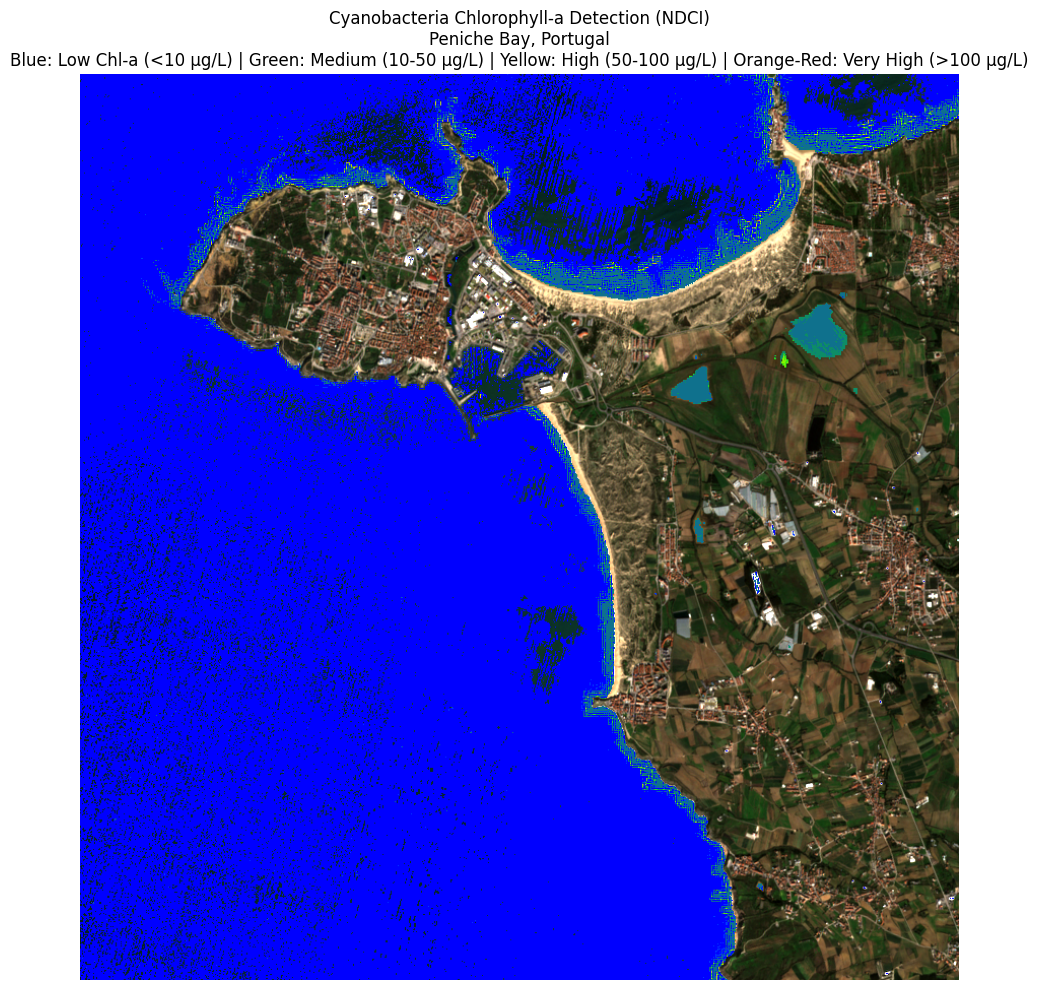

In [24]:
# Define output filename based on selected location
filename = f"ndci_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"

chl_a_image.download(filename)

# Load and display the image
img = Image.open(filename)

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    f"Cyanobacteria Chlorophyll-a Detection (NDCI)\n{current_params['location_name']}\n"
    "Blue: Low Chl-a (<10 μg/L) | Green: Medium (10-50 μg/L) | "
    "Yellow: High (50-100 μg/L) | Orange-Red: Very High (>100 μg/L)",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Export the Process Graph

Export the NDCI cyanobacteria pipeline as a reusable openEO User-Defined Process graph.

In [ ]:
import json

ndci_process_graph = {
    "process_graph": chl_a_image.flat_graph(),
    "parameters": [
        current_params["time"].to_dict(),
        current_params["bounding_box"].to_dict(),
        current_params["bands"].to_dict(),
    ],
    "id": "ndci_cyanobacteria",
    "summary": "Cyanobacteria Chlorophyll-a Detection using Sentinel-2 and NDCI",
    "description": (
        "Detects and quantifies cyanobacteria chlorophyll-a concentrations in "
        "water bodies using the Normalized Difference Chlorophyll Index (NDCI) "
        "combined with a water-body mask and the Floating Algae Index (FAI). "
        "Conversion of the Sentinel Hub CyanoLakes evalscript (Kravitz & Matthews, 2020)."
    ),
}

output_path = "ndci_cyanobacteria_process_graph.json"
with open(output_path, "w") as f:
    json.dump(ndci_process_graph, f, indent=2)

print(f"Process graph exported to {output_path}")
print(f"Process ID: {ndci_process_graph['id']}")

## Interpretation Guide

### Chlorophyll-a Concentration Levels:

| Color | Chl-a Range (μg/L) | Water Quality Status |
|-------|-------------------|----------------------|
| Deep Blue | < 0.5 | Ultra-oligotrophic (very clear) |
| Blue | 0.5 - 2.5 | Oligotrophic (clear) |
| Blue-Cyan | 2.5 - 8 | Mesotrophic (moderate) |
| Green | 8 - 24 | Eutrophic (nutrient-rich) |
| Yellow | 24 - 75 | Highly eutrophic |
| Orange | 75 - 150 | Hypereutrophic |
| Red | > 150 or FAI > 0.08 | Severe bloom / Floating algae |

### Applications:

- **Cyanobacteria Bloom Monitoring**: Early detection and tracking of harmful algal blooms
- **Water Quality Assessment**: Quantitative assessment of trophic status
- **Public Health Protection**: Identify areas with potential health risks
- **Lake Management**: Support decision-making for water treatment and management
- **Long-term Monitoring**: Track changes in water quality over time

### Model Specifications:

The NDCI model was calibrated using synthetic data with the following constraints:
- Non-algal particles (Cnap) < 10 μg/L
- CDOM absorption < 3 m⁻¹
- Chl-a concentrations < 500 μg/L
- Trained specifically on cyanobacteria *Microcystis aeruginosa*

**Model Performance:**
- Log Bias: 0.0023
- MAPE: 42.3%
- RMSE: 84.2 mg/m³
- Log RMSE: 0.99
- Relative RMSE: 95.8%

### Limitations:

1. Best suited for cyanobacteria-dominated blooms
2. May be less accurate in waters with very high turbidity or CDOM
3. Surface blooms may saturate the signal
4. L1C data used (top-of-atmosphere) - atmospheric effects present
5. Mixed phytoplankton assemblages may reduce accuracy

### Citation:

If using this algorithm, please cite:

Kravitz, J & Matthews M., 2020. Chlorophyll-a for cyanobacteria blooms from Sentinel-2. CyanoLakes.

### References:

- Hu, C. (2009). A novel ocean color index to detect floating algae in the global oceans. *Remote Sensing of Environment*, 113(10), 2118-2129.

- Kravitz, J., Matthews, M., Lain, L., Fawcett, S., & Bernard, S. (2021). Potential for high fidelity global mapping of common inland water quality products at high spatial and temporal resolutions based on a synthetic data and machine learning approach. *Frontiers in Environmental Science*, 19.

- Mishra, S., & Mishra, D. R. (2012). Normalized difference chlorophyll index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters. *Remote Sensing of Environment*, 117, 394-406.

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Cyanobacteria Chlorophyll-a (NDCI) - L1C](https://custom-scripts.sentinel-hub.com/sentinel-2/cyanobacteria_chla_ndci_l1c/)

**Author:** Johannah Kravitz, Mark Matthews (CyanoLakes)

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.

## Conclusion

This notebook demonstrates the implementation of the NDCI-based chlorophyll-a estimation for cyanobacteria detection using OpenEO and Sentinel-2 imagery. The method successfully:

- Identifies water bodies using multiple spectral indices
- Detects floating algae using FAI
- Estimates chlorophyll-a concentration using NDCI
- Produces color-mapped visualizations for easy interpretation

The approach can be extended to:
- Create time series animations of bloom development
- Generate statistical summaries by water body
- Integrate with early warning systems
- Support water quality modeling and forecasting
- Validate against in-situ measurements